In [1]:
#Import Libraries
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
#laod dataset
df = pd.read_csv("../data/smartcart_customers.csv")


In [3]:
#top 5 row
print(df.head())

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  MntFishProducts  MntSweetProducts  \
0  04-09-2012       58       635  ...              172                88   
1  08-03-2014       38        11  ...                2                 1   
2  21-08-2013       26       426  ...              111                21   
3  10-02-2014       26        11  ...               10                 3   
4  19-01-2014       94       173  ...               46                27   

   MntGoldProds  NumDealsPurchases  NumWebPurchases  NumCatalogPurchases  

In [4]:
#dataset shape
print(df.shape)

(2240, 22)


In [5]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [6]:
#dataset description

df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.009375,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.096391,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000


In [7]:
#null value check
df.isnull().sum().sort_values(ascending=False)

Income                 24
ID                      0
MntFishProducts         0
Complain                0
NumWebVisitsMonth       0
NumStorePurchases       0
NumCatalogPurchases     0
NumWebPurchases         0
NumDealsPurchases       0
MntGoldProds            0
MntSweetProducts        0
MntMeatProducts         0
Year_Birth              0
MntFruits               0
MntWines                0
Recency                 0
Dt_Customer             0
Teenhome                0
Kidhome                 0
Marital_Status          0
Education               0
Response                0
dtype: int64

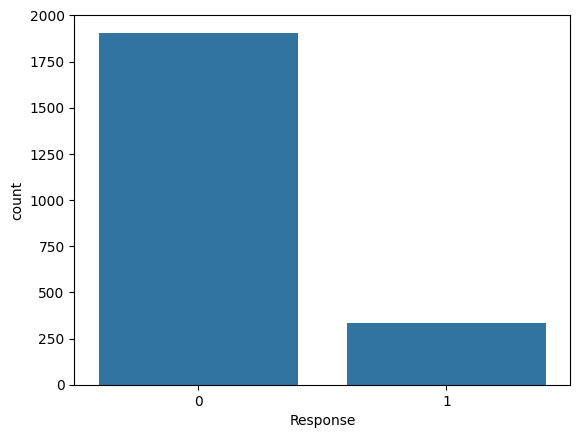

In [8]:
#info about the target column
target_col = 'Response'  
sns.countplot(x=df[target_col])
plt.show()


In [9]:
#Separate Features and Target
X = df.drop("Response", axis=1)
y = df["Response"]
X

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,546,172,88,88,3,8,10,4,7,0
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,6,2,1,6,2,1,1,2,5,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,127,111,21,42,1,8,2,10,4,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,20,10,3,5,2,2,0,4,6,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,118,46,27,15,5,5,3,6,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,182,42,118,247,2,9,3,4,5,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,30,0,0,8,7,8,2,5,7,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,217,32,12,24,1,2,3,13,6,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,214,80,30,61,2,6,5,10,3,0


In [10]:
#  Identify Column Types
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: Index(['Education', 'Marital_Status', 'Dt_Customer'], dtype='str')
Numeric columns: Index(['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain'],
      dtype='str')


In [11]:
# Preprocessing Pipelines
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

# Numeric pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # ✅ fill NaN
    ("scaler", StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),  # ✅ fill NaN
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# Combine
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numeric_cols),
    ("cat", cat_pipeline, categorical_cols)
])

In [12]:
# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1792, 21), (448, 21), (1792,), (448,))

In [13]:
# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed = X_train_processed.toarray()
X_test_processed = X_test_processed.toarray()

In [14]:
# PCA (Dimensionality Reduction)
pca = PCA(n_components=0.95, svd_solver='full')

X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

In [15]:
#  K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)

train_clusters = kmeans.fit_predict(X_train_pca)
test_clusters = kmeans.predict(X_test_pca)

In [16]:
# Add cluster feature
X_train_final = np.hstack([X_train_pca, train_clusters.reshape(-1, 1)])
X_test_final = np.hstack([X_test_pca, test_clusters.reshape(-1, 1)])

In [17]:
# Apply SMOTE to balance the training set
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_final, y_train)

print('Balanced training set shape:', X_train_bal.shape, y_train_bal.shape)
print('Class distribution after SMOTE:', np.bincount(y_train_bal))


Balanced training set shape: (3050, 26) (3050,)
Class distribution after SMOTE: [1525 1525]


In [18]:
# XGBoost with RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

xgb_param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'scale_pos_weight': [1, float(np.sum(y_train_bal==0)/np.sum(y_train_bal==1))]
}
xgb = XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
xgb_rs = RandomizedSearchCV(xgb, param_distributions=xgb_param_dist, n_iter=20, cv=3, scoring='f1', n_jobs=-1, random_state=42, verbose=1)
xgb_rs.fit(X_train_bal, y_train_bal)
print('Best XGBoost parameters:', xgb_rs.best_params_)
# Train best XGBoost model
best_xgb = xgb_rs.best_estimator_
best_xgb.fit(X_train_bal, y_train_bal)
y_pred_xgb = best_xgb.predict(X_test_final)
print('XGBoost Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_xgb))
print('\nXGBoost Classification Report:')
print(classification_report(y_test, y_pred_xgb))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best XGBoost parameters: {'subsample': 0.7, 'scale_pos_weight': 1.0, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
XGBoost Confusion Matrix:
[[344  37]
 [ 36  31]]

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90       381
           1       0.46      0.46      0.46        67

    accuracy                           0.84       448
   macro avg       0.68      0.68      0.68       448
weighted avg       0.84      0.84      0.84       448

